# Kemuel Marvila 21.1.4013

In [47]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")

# carregar os conjuntos de dados de treino e teste.

In [48]:
# Carregar os dados
data_dir = "../house-prices-data/"
try:
    # Tente carregar do seu ambiente local
    train_df = pd.read_csv(data_dir + 'train.csv')
    test_df = pd.read_csv(data_dir + 'test.csv')
except FileNotFoundError:
    print("Arquivos 'train.csv' e 'test.csv' não encontrados. Certifique-se de que estão no diretório correto.")
# Visualizar as primeiras linhas do conjunto de treino
if not train_df.empty:
    print("Amostra do Conjunto de Treino:")
    display(train_df.head())

# Guardar o ID do conjunto de teste para a submissão final
if not test_df.empty:
    test_id = test_df['Id']

# Unir os dataframes para pré-processamento (exceto o alvo 'SalePrice')
if not train_df.empty and not test_df.empty:
    all_data = pd.concat((train_df.loc[:,'MSSubClass':'SaleCondition'],
                          test_df.loc[:,'MSSubClass':'SaleCondition']),
                         ignore_index=True)
    y_train = train_df['SalePrice']

Amostra do Conjunto de Treino:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Identificação dos Tipos de Atributos

In [49]:
# Atributos Numéricos:
'''
Contínuos: Representam medidas que podem assumir qualquer valor dentro de um intervalo.

LotFrontage: Pés lineares de rua conectados à propriedade.
LotArea: Tamanho do lote em pés quadrados.
MasVnrArea: Área de revestimento de alvenaria em pés quadrados.
BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF: Áreas do porão.
1stFlrSF, 2ndFlrSF, GrLivArea: Áreas de estar.
GarageArea: Área da garagem em pés quadrados.
WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch: Áreas de varanda/deck.
PoolArea: Área da piscina.
MiscVal: Valor de recursos diversos.
SalePrice (Alvo): Preço de venda.
'''
'''
Discretos: Representam contagens ou valores inteiros.

YearBuilt, YearRemodAdd, GarageYrBlt: Anos de construção/reforma.
MoSold, YrSold: Mês e ano da venda.
BsmtFullBath, BsmtHalfBath, FullBath, HalfBath: Número de banheiros.
BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd: Número de cômodos.
Fireplaces: Número de lareiras.
GarageCars: Capacidade da garagem em carros.
'''

'\nDiscretos: Representam contagens ou valores inteiros.\n\nYearBuilt, YearRemodAdd, GarageYrBlt: Anos de construção/reforma.\nMoSold, YrSold: Mês e ano da venda.\nBsmtFullBath, BsmtHalfBath, FullBath, HalfBath: Número de banheiros.\nBedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd: Número de cômodos.\nFireplaces: Número de lareiras.\nGarageCars: Capacidade da garagem em carros.\n'

In [50]:
# Atributos Categóricos:
'''
Nominais: As categorias não possuem uma ordem intrínseca.

MSSubClass: Tipo de moradia (apesar de numérico, é um código categórico).
MSZoning: Classificação de zoneamento.
Street: Tipo de acesso à rua.
Alley: Tipo de acesso ao beco.
LandContour: Planicidade da propriedade.
LotConfig: Configuração do lote.
Neighborhood: Localização física.
Condition1, Condition2: Proximidade a várias condições.
BldgType: Tipo de moradia.
HouseStyle: Estilo da moradia.
RoofStyle, RoofMatl: Estilo e material do telhado.
Exterior1st, Exterior2nd: Revestimento externo.
MasVnrType: Tipo de revestimento de alvenaria.
Foundation: Tipo de fundação.
Heating: Tipo de aquecimento.
CentralAir: Ar condicionado central (Binário Simétrico).
GarageType: Localização da garagem.
MiscFeature: Recurso miscelâneo.
SaleType, SaleCondition: Tipo e condição da venda.
'''
'''
Ordinais: As categorias possuem uma ordem clara e lógica.

LotShape: Forma geral da propriedade (Reg > IR1 > IR2 > IR3).
Utilities: Tipo de utilidades disponíveis.
LandSlope: Inclinação da propriedade (Gtl > Mod > Sev).
OverallQual, OverallCond: Qualidade e condição geral (1-10).
ExterQual, ExterCond: Qualidade e condição do exterior (Po, Fa, TA, Gd, Ex).
BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2: Atributos do porão com qualificação/ordem.
HeatingQC: Qualidade do aquecimento.
Electrical: Sistema elétrico.
KitchenQual: Qualidade da cozinha.
Functional: Funcionalidade da casa.
FireplaceQu: Qualidade da lareira.
GarageFinish: Acabamento interno da garagem.
GarageQual, GarageCond: Qualidade e condição da garagem.
PavedDrive: Calçada pavimentada.
PoolQC: Qualidade da piscina.
Fence: Qualidade da cerca.
'''

'\nOrdinais: As categorias possuem uma ordem clara e lógica.\n\nLotShape: Forma geral da propriedade (Reg > IR1 > IR2 > IR3).\nUtilities: Tipo de utilidades disponíveis.\nLandSlope: Inclinação da propriedade (Gtl > Mod > Sev).\nOverallQual, OverallCond: Qualidade e condição geral (1-10).\nExterQual, ExterCond: Qualidade e condição do exterior (Po, Fa, TA, Gd, Ex).\nBsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2: Atributos do porão com qualificação/ordem.\nHeatingQC: Qualidade do aquecimento.\nElectrical: Sistema elétrico.\nKitchenQual: Qualidade da cozinha.\nFunctional: Funcionalidade da casa.\nFireplaceQu: Qualidade da lareira.\nGarageFinish: Acabamento interno da garagem.\nGarageQual, GarageCond: Qualidade e condição da garagem.\nPavedDrive: Calçada pavimentada.\nPoolQC: Qualidade da piscina.\nFence: Qualidade da cerca.\n'

In [51]:
# Atributos Binários:
'''
CentralAir pode ser considerado um atributo binário (Y/N). 
	A sua natureza é assimétrica se um dos valores for mais importante para a análise (por exemplo, ter ar condicionado é mais informativo do que não ter).
'''

'\nCentralAir pode ser considerado um atributo binário (Y/N). \n\tA sua natureza é assimétrica se um dos valores for mais importante para a análise (por exemplo, ter ar condicionado é mais informativo do que não ter).\n'

Iniciando cálculo de Informação Mútua...

--- Top 30 Atributos Mais Relevantes por Informação Mútua ---
OverallQual     0.564319
Neighborhood    0.502301
GrLivArea       0.482313
GarageCars      0.368256
TotalBsmtSF     0.366934
YearBuilt       0.366387
GarageArea      0.366115
BsmtQual        0.329119
KitchenQual     0.318267
1stFlrSF        0.309579
ExterQual       0.306704
GarageYrBlt     0.298899
MSSubClass      0.279689
FullBath        0.271870
GarageFinish    0.261872
YearRemodAdd    0.252671
LotFrontage     0.218467
TotRmsAbvGrd    0.214940
GarageType      0.209591
2ndFlrSF        0.205615
FireplaceQu     0.205548
Foundation      0.191581
HeatingQC       0.168878
Exterior2nd     0.165029
Fireplaces      0.164154
LotArea         0.159205
BsmtFinType1    0.151218
BsmtFinSF1      0.148321
OpenPorchSF     0.145932
Exterior1st     0.130290


/tmp/ipykernel_24119/155637980.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mi.values, y=top_mi.index, palette="viridis")


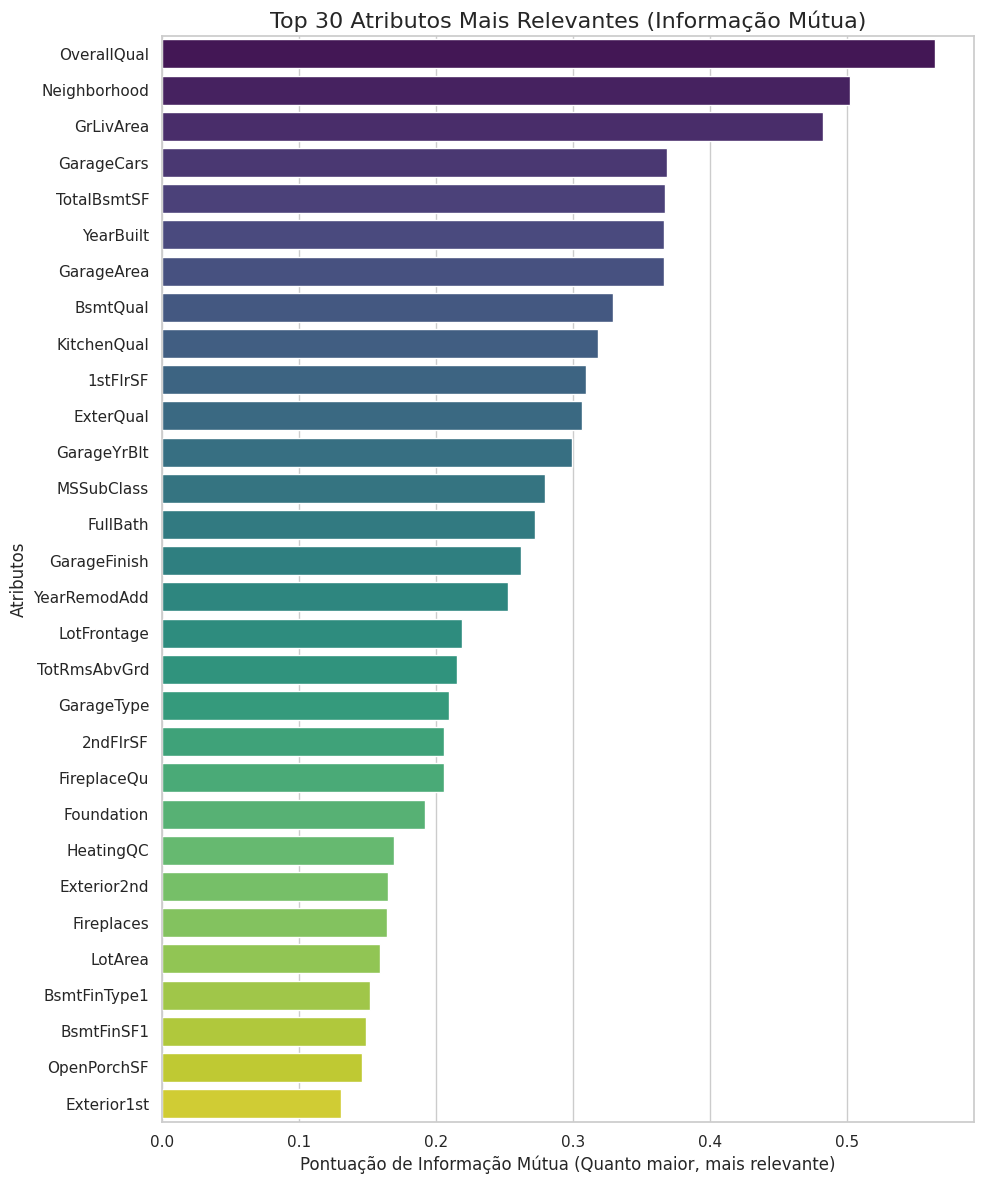

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

def plotar_informacao_mutua(df):
    """
    Calcula e plota a Informação Mútua entre os atributos de um dataframe e a coluna 'SalePrice'.

    Args:
        df (pd.DataFrame): O dataframe de treino contendo os atributos e a coluna 'SalePrice'.
    """
    print("Iniciando cálculo de Informação Mútua...")

    # 1. Preparar os dados
    df_mi = df.copy()
    if 'Id' in df_mi.columns:
        df_mi = df_mi.drop('Id', axis=1)

    # Tratar valores ausentes (NaN) antes do encoding
    # Para colunas numéricas, usamos a mediana
    for col in df_mi.select_dtypes(include=np.number):
        if df_mi[col].isnull().any():
            df_mi[col] = df_mi[col].fillna(df_mi[col].median())
            
    # Para colunas de texto (categóricas), usamos um valor placeholder
    for col in df_mi.select_dtypes("object"):
        if df_mi[col].isnull().any():
            df_mi[col] = df_mi[col].fillna("missing")

    # Converter colunas categóricas para um formato numérico que a função entende
    for col in df_mi.select_dtypes("object"):
        df_mi[col], _ = pd.factorize(df_mi[col])

    # 2. Separar features (X) e alvo (y)
    X = df_mi.drop('SalePrice', axis=1)
    y = df_mi['SalePrice']

    # 3. Calcular Informação Mútua
    # O random_state garante que o resultado seja o mesmo toda vez que rodar
    mi_scores = mutual_info_regression(X, y, random_state=0)
    mi_scores = pd.Series(mi_scores, name="Pontuação MI", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)

    # 4. Exibir os resultados
    print("\n--- Top 30 Atributos Mais Relevantes por Informação Mútua ---")
    print(mi_scores.head(30).to_string())

    # Plotar os 30 atributos mais relevantes
    plt.figure(figsize=(10, 12))
    top_mi = mi_scores.head(30)
    sns.set_style("whitegrid")
    sns.barplot(x=top_mi.values, y=top_mi.index, palette="viridis")
    plt.title('Top 30 Atributos Mais Relevantes (Informação Mútua)', fontsize=16)
    plt.xlabel('Pontuação de Informação Mútua (Quanto maior, mais relevante)', fontsize=12)
    plt.ylabel('Atributos', fontsize=12)
    plt.tight_layout()
    plt.show()


# --- Como usar a função no seu notebook ---
# Certifique-se de que seu dataframe 'train_df' está carregado
# train_df = pd.read_csv('../house-prices-data/train.csv') 

# Em seguida, simplesmente chame a função:
plotar_informacao_mutua(train_df)

##  Análise de Atributos Numéricos

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


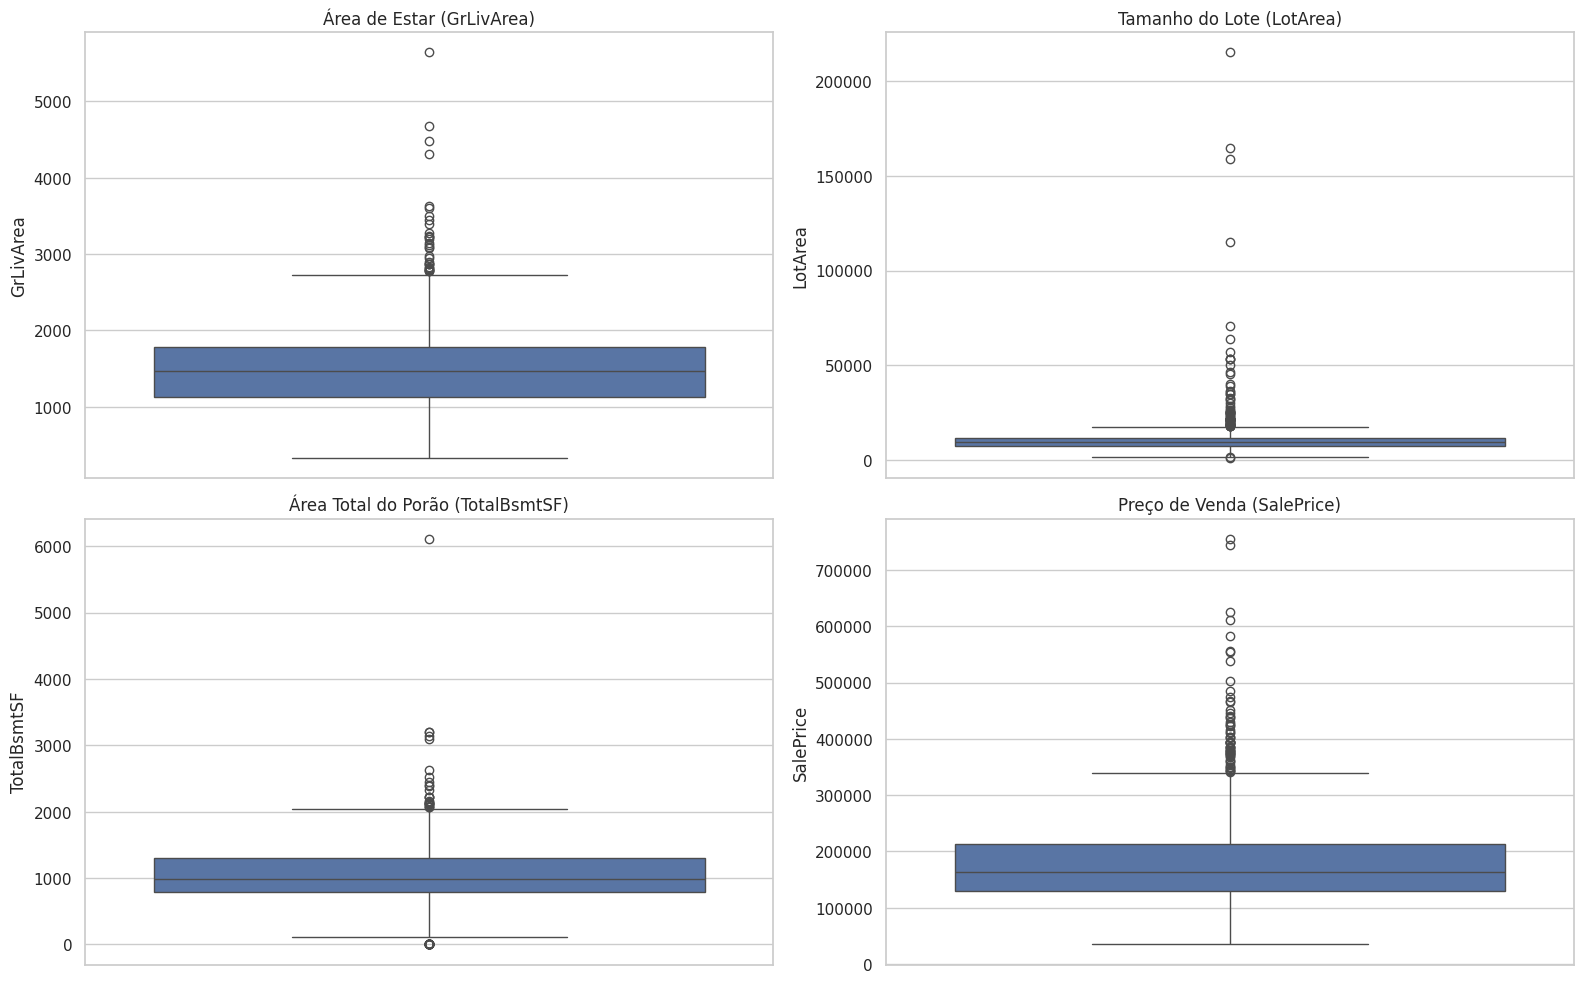

In [53]:
# Resumo estatístico para os atributos numéricos do conjunto de treino
if not train_df.empty:
    display(train_df.describe().transpose())

# Visualização de outliers para algumas variáveis contínuas importantes
if not train_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    sns.boxplot(y=train_df['GrLivArea'], ax=axes[0, 0]).set_title('Área de Estar (GrLivArea)')
    sns.boxplot(y=train_df['LotArea'], ax=axes[0, 1]).set_title('Tamanho do Lote (LotArea)')
    sns.boxplot(y=train_df['TotalBsmtSF'], ax=axes[1, 0]).set_title('Área Total do Porão (TotalBsmtSF)')
    sns.boxplot(y=train_df['SalePrice'], ax=axes[1, 1]).set_title('Preço de Venda (SalePrice)')
    plt.tight_layout()
    plt.show()

In [54]:
'''
Distribuição Assimétrica: Variáveis importantes como LotArea (Área do Lote) e a nossa variável alvo, SalePrice (Preço de Venda), 
	apresentam uma média (mean) consideravelmente maior que a mediana (50%). 
    Isso, junto com um valor máximo (max) muito distante do quartil superior (75%), 
    	indica uma distribuição assimétrica à direita e a provável existência de outliers (valores aberrantes) que podem impactar o desempenho do modelo.
Dados Faltantes: A contagem (count) para LotFrontage é de 1201, menor que o total de 1460 registros, confirmando a presença de dados ausentes que precisarão de tratamento.
	É extremamente improvável que uma casa não tenha nenhuma fachada ou conexão com a rua (um valor de 0 pés). Uma casa precisa de acesso.
Intervalos: As variáveis de qualidade, como OverallQual, estão contidas no intervalo esperado de 1 a 10.
'''
'''
SalePrice (Preço de Venda)
Motivo: É a variável-alvo, o dado que queremos prever. É a variável mais importante de todo o projeto.
GrLivArea (Área de Estar)
Motivo: Representa a "Área de Estar Acima do Solo". Esta é, intuitivamente, a característica que a maioria das pessoas associa ao tamanho e valor de uma casa.
LotArea (Tamanho do Lote)
Motivo: Uma casa não é apenas a construção, mas também o terreno em que ela se encontra. O tamanho do lote é um fator fundamental no valor total de um imóvel.
TotalBsmtSF (Área Total do Porão)
Motivo: Complementa a GrLivArea para dar uma ideia da área construída total da propriedade. Um porão grande e bem acabado pode adicionar um valor significativo.
'''

'\nSalePrice (Preço de Venda)\nMotivo: É a variável-alvo, o dado que queremos prever. É a variável mais importante de todo o projeto.\nGrLivArea (Área de Estar)\nMotivo: Representa a "Área de Estar Acima do Solo". Esta é, intuitivamente, a característica que a maioria das pessoas associa ao tamanho e valor de uma casa.\nLotArea (Tamanho do Lote)\nMotivo: Uma casa não é apenas a construção, mas também o terreno em que ela se encontra. O tamanho do lote é um fator fundamental no valor total de um imóvel.\nTotalBsmtSF (Área Total do Porão)\nMotivo: Complementa a GrLivArea para dar uma ideia da área construída total da propriedade. Um porão grande e bem acabado pode adicionar um valor significativo.\n'

## Análise de Atributos Categóricos

In [55]:
# Exemplo para alguns atributos categóricos nominais e ordinais
if not train_df.empty:
    print("Distribuição de 'MSZoning':")
    print(train_df['MSZoning'].value_counts(normalize=True) * 100)
    print("\n--------------------\n")

    print("Distribuição de 'OverallQual':")
    print(train_df['OverallQual'].value_counts(normalize=True).sort_index() * 100)
    print("\n--------------------\n")

    print("Distribuição de 'CentralAir':")
    print(train_df['CentralAir'].value_counts(normalize=True) * 100)

Distribuição de 'MSZoning':
MSZoning
RL         78.835616
RM         14.931507
FV          4.452055
RH          1.095890
C (all)     0.684932
Name: proportion, dtype: float64

--------------------

Distribuição de 'OverallQual':
OverallQual
1      0.136986
2      0.205479
3      1.369863
4      7.945205
5     27.191781
6     25.616438
7     21.849315
8     11.506849
9      2.945205
10     1.232877
Name: proportion, dtype: float64

--------------------

Distribuição de 'CentralAir':
CentralAir
Y    93.493151
N     6.506849
Name: proportion, dtype: float64


In [56]:
'''
Desbalanceamento de Classes: Em MSZoning, a categoria RL (Residencial de Baixa Densidade) é predominante, correspondendo a quase 79% dos casos. 
	Este desbalanceamento é comum em dados do mundo real.
Distribuição Esperada: OverallQual (Qualidade Geral) mostra uma distribuição próxima da normal, com a maioria das casas concentradas nas qualidades médias (5, 6 e 7).
Característica Binária: CentralAir (Ar Condicionado Central) é um atributo binário onde a grande maioria das casas (93.5%) possui a característica.
'''

'\nDesbalanceamento de Classes: Em MSZoning, a categoria RL (Residencial de Baixa Densidade) é predominante, correspondendo a quase 79% dos casos. \n\tEste desbalanceamento é comum em dados do mundo real.\nDistribuição Esperada: OverallQual (Qualidade Geral) mostra uma distribuição próxima da normal, com a maioria das casas concentradas nas qualidades médias (5, 6 e 7).\nCaracterística Binária: CentralAir (Ar Condicionado Central) é um atributo binário onde a grande maioria das casas (93.5%) possui a característica.\n'

## Identificação de Valores Ausentes (Missing Values)

In [57]:
# Contagem de valores ausentes por coluna
if 'all_data' in locals() and not all_data.empty:
    missing_values = all_data.isnull().sum().sort_values(ascending=False)
    missing_percent = (all_data.isnull().sum() / len(all_data) * 100).sort_values(ascending=False)
    missing_data = pd.concat([missing_values, missing_percent], axis=1, keys=['Total', 'Percentual'])
    
    print("Valores Ausentes no Conjunto de Dados Combinado:")
    display(missing_data[missing_data['Total'] > 0])

Valores Ausentes no Conjunto de Dados Combinado:


,Total,Percentual
PoolQC,2909,99.657417
MiscFeature,2814,96.402878
Alley,2721,93.216855
Fence,2348,80.438506
MasVnrType,1766,60.500171
FireplaceQu,1420,48.646797
LotFrontage,486,16.649538
GarageCond,159,5.447071
GarageFinish,159,5.447071
GarageYrBlt,159,5.447071


In [58]:
'''
A análise mostra que colunas como PoolQC, MiscFeature e Alley possuem um percentual de ausência superior a 90%. 
	No entanto, uma leitura atenta da documentação revela que estes não são dados perdidos, mas sim uma categoria que representa a ausência da característica (ex: "Sem Piscina"). 
    Esta distinção é fundamental para a etapa de limpeza.

Outras colunas, como LotFrontage (16.6% ausentes) e as diversas variáveis de garagem (Garage...), representam dados genuinamente faltantes ou ausência de garagem, 
	exigindo estratégias de preenchimento específicas.
'''

'\nA análise mostra que colunas como PoolQC, MiscFeature e Alley possuem um percentual de ausência superior a 90%. \n\tNo entanto, uma leitura atenta da documentação revela que estes não são dados perdidos, mas sim uma categoria que representa a ausência da característica (ex: "Sem Piscina"). \n    Esta distinção é fundamental para a etapa de limpeza.\n\nOutras colunas, como LotFrontage (16.6% ausentes) e as diversas variáveis de garagem (Garage...), representam dados genuinamente faltantes ou ausência de garagem, \n\texigindo estratégias de preenchimento específicas.\n'

## Correlação entre Atributos Numéricos

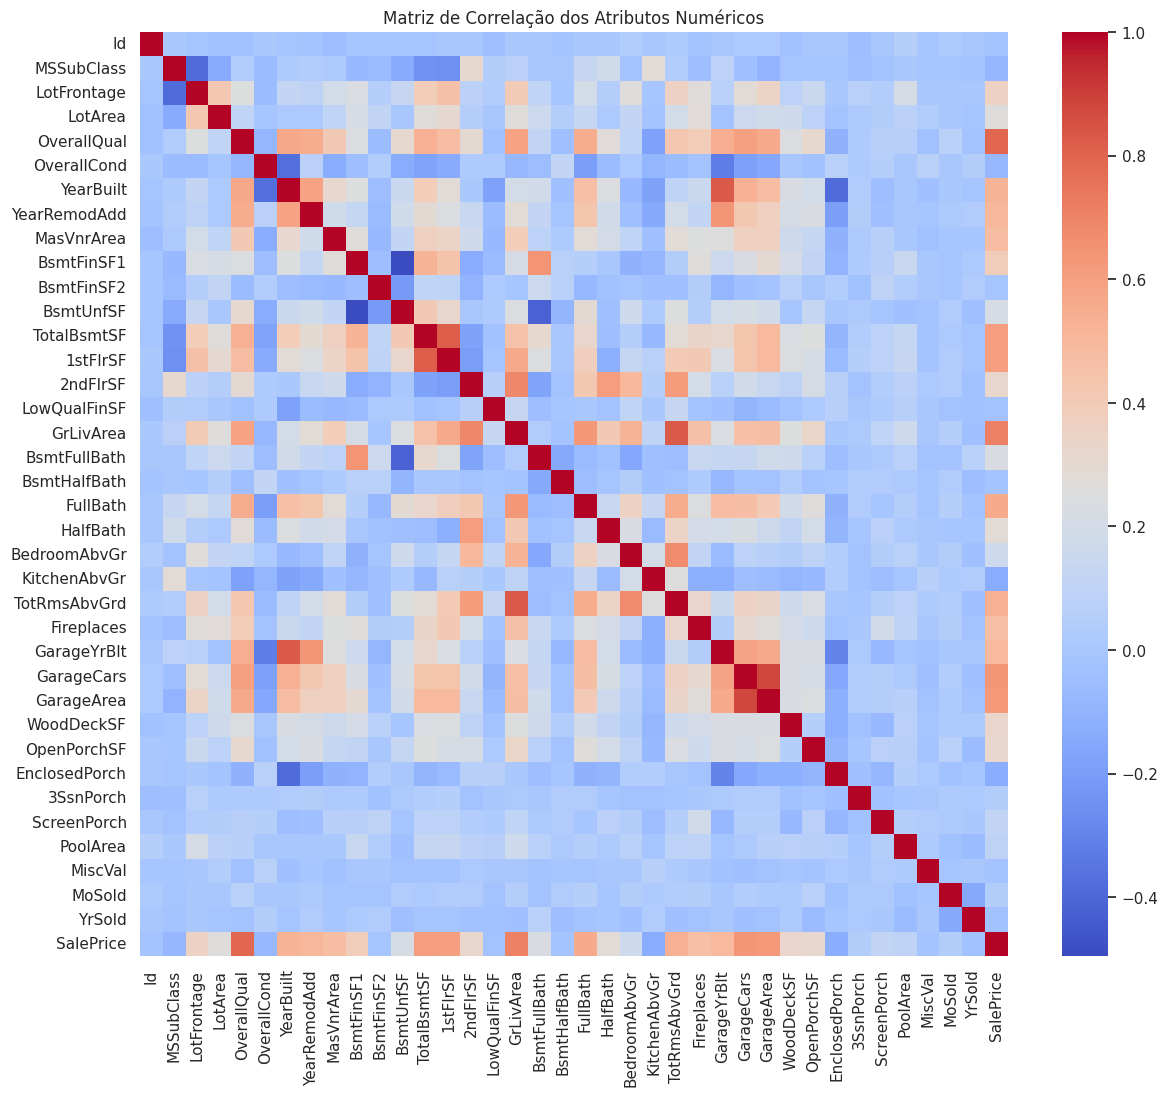

Top 15 correlações com SalePrice:


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

In [59]:
# Matriz de correlação para o conjunto de treino
if not train_df.empty:
    correlation_matrix = train_df.select_dtypes(include=[np.number]).corr()
    
    # Plotar o heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
    plt.title('Matriz de Correlação dos Atributos Numéricos')
    plt.show()

    # Mostrar as correlações mais fortes com SalePrice
    print("Top 15 correlações com SalePrice:")
    display(correlation_matrix['SalePrice'].sort_values(ascending=False).head(16))

In [60]:
'''
Preditores Fortes: OverallQual (Qualidade Geral) apresenta a correlação positiva mais forte (0.79), 
	indicando que a qualidade do material e acabamento é o fator mais importante para o preço. 
    GrLivArea (Área de Estar) segue como o segundo preditor mais forte (0.71).
Multicolinearidade: Nota-se uma alta correlação entre GarageCars (vagas na garagem) e GarageArea (área da garagem). 
	Como elas carregam informações muito similares, a utilização de apenas uma delas pode ser suficiente para evitar redundância no modelo.
    TotalBsmtSF e 1stFlrSF, indica que existe muito area do porao no primeiro andar.
'''

'\nPreditores Fortes: OverallQual (Qualidade Geral) apresenta a correlação positiva mais forte (0.79), \n\tindicando que a qualidade do material e acabamento é o fator mais importante para o preço. \n    GrLivArea (Área de Estar) segue como o segundo preditor mais forte (0.71).\nMulticolinearidade: Nota-se uma alta correlação entre GarageCars (vagas na garagem) e GarageArea (área da garagem). \n\tComo elas carregam informações muito similares, a utilização de apenas uma delas pode ser suficiente para evitar redundância no modelo.\n    TotalBsmtSF e 1stFlrSF, indica que existe muito area do porao no primeiro andar.\n'

# Limpeza e Transformação de Dados

## 2.a Preenchimento de Valores Ausentes

In [61]:
print("Iniciando o preenchimento de valores ausentes...")

# Categoria 'None' para características que, quando ausentes, significam 'Nenhuma'
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 
            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
            'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']:
    all_data[col] = all_data[col].fillna('None')

# Zero para áreas/contagens numéricas que estão ausentes (geralmente em casas sem a característica)
for col in ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 
            'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']:
    all_data[col] = all_data[col].fillna(0)

# Moda (valor mais frequente) para atributos categóricos com poucos valores ausentes
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])
all_data['Functional'] = all_data['Functional'].fillna('Typ') # 'Typ' (Typical) é o valor mais comum segundo a documentação.

# Corrigindo os 2 valores ausentes restantes na coluna 'Utilities'
all_data['Utilities'] = all_data['Utilities'].fillna(all_data['Utilities'].mode()[0])

# Estratégia específica para 'LotFrontage': preencher com a mediana da vizinhança
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# Verificação final: agora o resultado deve ser 0
print("Verificando valores ausentes restantes após a correção...")
print("Total de valores ausentes no dataframe:", all_data.isnull().sum().sum())

if all_data.isnull().sum().sum() == 0:
    print("Sucesso! Todos os valores ausentes foram tratados.")
else:
    print("Atenção! Ainda existem valores ausentes. Verifique as colunas:")
    display(all_data.isnull().sum()[all_data.isnull().sum() > 0])

Iniciando o preenchimento de valores ausentes...
Verificando valores ausentes restantes após a correção...
Total de valores ausentes no dataframe: 0
Sucesso! Todos os valores ausentes foram tratados.


In [62]:
'''
Para garantir a qualidade dos dados, foi implementada uma estratégia de imputação multifacetada. 
Para colunas como Alley, onde NaN indicava "Sem Beco", os valores foram preenchidos com a categoria 'None'. 
Para a variável numérica LotFrontage, utilizou-se a mediana da vizinhança, uma abordagem mais robusta que a média global. 
As demais colunas com poucos valores ausentes foram preenchidas com o valor mais frequente (moda).
'''

'\nPara garantir a qualidade dos dados, foi implementada uma estratégia de imputação multifacetada. \nPara colunas como Alley, onde NaN indicava "Sem Beco", os valores foram preenchidos com a categoria \'None\'. \nPara a variável numérica LotFrontage, utilizou-se a mediana da vizinhança, uma abordagem mais robusta que a média global. \nAs demais colunas com poucos valores ausentes foram preenchidas com o valor mais frequente (moda).\n'

## 2.b Suavize os ruídos (use o qcut ou cut para dividir os bins ou algum método supervisionado).

In [63]:
# qcut 
all_data['YearBuilt_binned'] = pd.qcut(all_data['YearBuilt'], q=10, labels=False, duplicates='drop')

##  2.c Resolva as inconsistências, se houver. Se não houver, explique porque não há.

In [64]:
# nao teve nada. na etapa 2 ja corrige os NaN para None. fazer o mapeamento das variáveis ordinais antes de aplicar o one-hot encoding nas variáveis nominais.

Teve que inverter a ordem, primeiro 2.e e depois o 2.d

## 2.e Transformação de Atributos Categóricos Ordinais

In [65]:
print("Iniciando mapeamento de variáveis ordinais...")

# Dicionários de mapeamento
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
slope_map = {'Gtl': 0, 'Mod': 1, 'Sev': 2}
finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}

# Aplicar mapeamento
all_data['ExterQual'] = all_data['ExterQual'].map(qual_map)
all_data['ExterCond'] = all_data['ExterCond'].map(qual_map)
all_data['BsmtQual'] = all_data['BsmtQual'].map(qual_map)
all_data['BsmtCond'] = all_data['BsmtCond'].map(qual_map)
all_data['HeatingQC'] = all_data['HeatingQC'].map(qual_map)
all_data['KitchenQual'] = all_data['KitchenQual'].map(qual_map)
all_data['FireplaceQu'] = all_data['FireplaceQu'].map(qual_map)
all_data['GarageQual'] = all_data['GarageQual'].map(qual_map)
all_data['GarageCond'] = all_data['GarageCond'].map(qual_map)
all_data['PoolQC'] = all_data['PoolQC'].map(qual_map)

all_data['LandSlope'] = all_data['LandSlope'].map(slope_map)
all_data['GarageFinish'] = all_data['GarageFinish'].map(finish_map)
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(exposure_map)

# Exemplo de visualização após o mapeamento
print("\nValores de 'ExterQual' após mapeamento:")
print(all_data['ExterQual'].value_counts())

Iniciando mapeamento de variáveis ordinais...

Valores de 'ExterQual' após mapeamento:
ExterQual
3    1798
4     979
5     107
2      35
Name: count, dtype: int64


## 2.d Transformação de Atributos Categóricos Nominais

In [66]:
print("Shape do dataframe antes One-Hot Encoding:", all_data.shape)

# Transformar a variável MSSubClass em categórica antes do encoding
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)

# Aplicar One-Hot Encoding
all_data = pd.get_dummies(all_data, drop_first=True)

print("Shape do dataframe após One-Hot Encoding:", all_data.shape)

Shape do dataframe antes One-Hot Encoding: (2919, 80)
Shape do dataframe após One-Hot Encoding: (2919, 238)


In [67]:
'''
Mapeamento Ordinal: Variáveis com uma ordem intrínseca, como ExterQual (Qualidade Exterior), foram mapeadas para valores numéricos (TA -> 3, Gd -> 4, etc.), mantendo sua hierarquia.
One-Hot Encoding: Para as variáveis nominais restantes (sem ordem), como MSZoning, foi aplicada a técnica de One-Hot Encoding. 
	Isso resultou na expansão do número de colunas de ~80 para 238, criando um vetor numérico que pode ser processado pelos algoritmos de machine learning sem assumir uma relação de ordem falsa entre as categorias.
'''
'''
Variáveis Ordinais (Onde a Ordem Importa): substituir por um número, como {'Razoável': 2, 'Típico': 3, 'Bom': 4}
Variáveis Nominais (Onde a Ordem NÃO Importa): São categorias que são apenas rótulos, sem nenhuma ordem ou hierarquia entre si.
	Se fizéssemos {'OldTown': 1, 'Somerst': 2, 'Edwards': 3}, o modelo aprenderia uma relação matemática falsa. 
    Ele passaria a achar que Edwards > Somerst (pois 3 > 2) e que a "distância" entre "OldTown" e "Edwards" é o triplo da distância para "Somerst". 
    Essa ordem não existe na realidade e essa informação falsa iria confundir o modelo e piorar muito sua performance.
One-hot: O que ele faz: Em vez de criar uma única coluna com números falsos, ele cria novas colunas binárias (0 ou 1) para cada categoria.
Dessa forma, o modelo aprende que a casa pertence a uma categoria específica, sem criar nenhuma relação de ordem falsa entre elas. 
Cada vizinhança é tratada como uma característica independente, que pode ou não influenciar o preço.
'''

'\nVariáveis Ordinais (Onde a Ordem Importa): substituir por um número, como {\'Razoável\': 2, \'Típico\': 3, \'Bom\': 4}\nVariáveis Nominais (Onde a Ordem NÃO Importa): São categorias que são apenas rótulos, sem nenhuma ordem ou hierarquia entre si.\n\tSe fizéssemos {\'OldTown\': 1, \'Somerst\': 2, \'Edwards\': 3}, o modelo aprenderia uma relação matemática falsa. \n    Ele passaria a achar que Edwards > Somerst (pois 3 > 2) e que a "distância" entre "OldTown" e "Edwards" é o triplo da distância para "Somerst". \n    Essa ordem não existe na realidade e essa informação falsa iria confundir o modelo e piorar muito sua performance.\nOne-hot: O que ele faz: Em vez de criar uma única coluna com números falsos, ele cria novas colunas binárias (0 ou 1) para cada categoria.\nDessa forma, o modelo aprende que a casa pertence a uma categoria específica, sem criar nenhuma relação de ordem falsa entre elas. \nCada vizinhança é tratada como uma característica independente, que pode ou não influen

/tmp/ipykernel_24119/1929562870.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlations.values, y=top_correlations.index, palette="vlag")


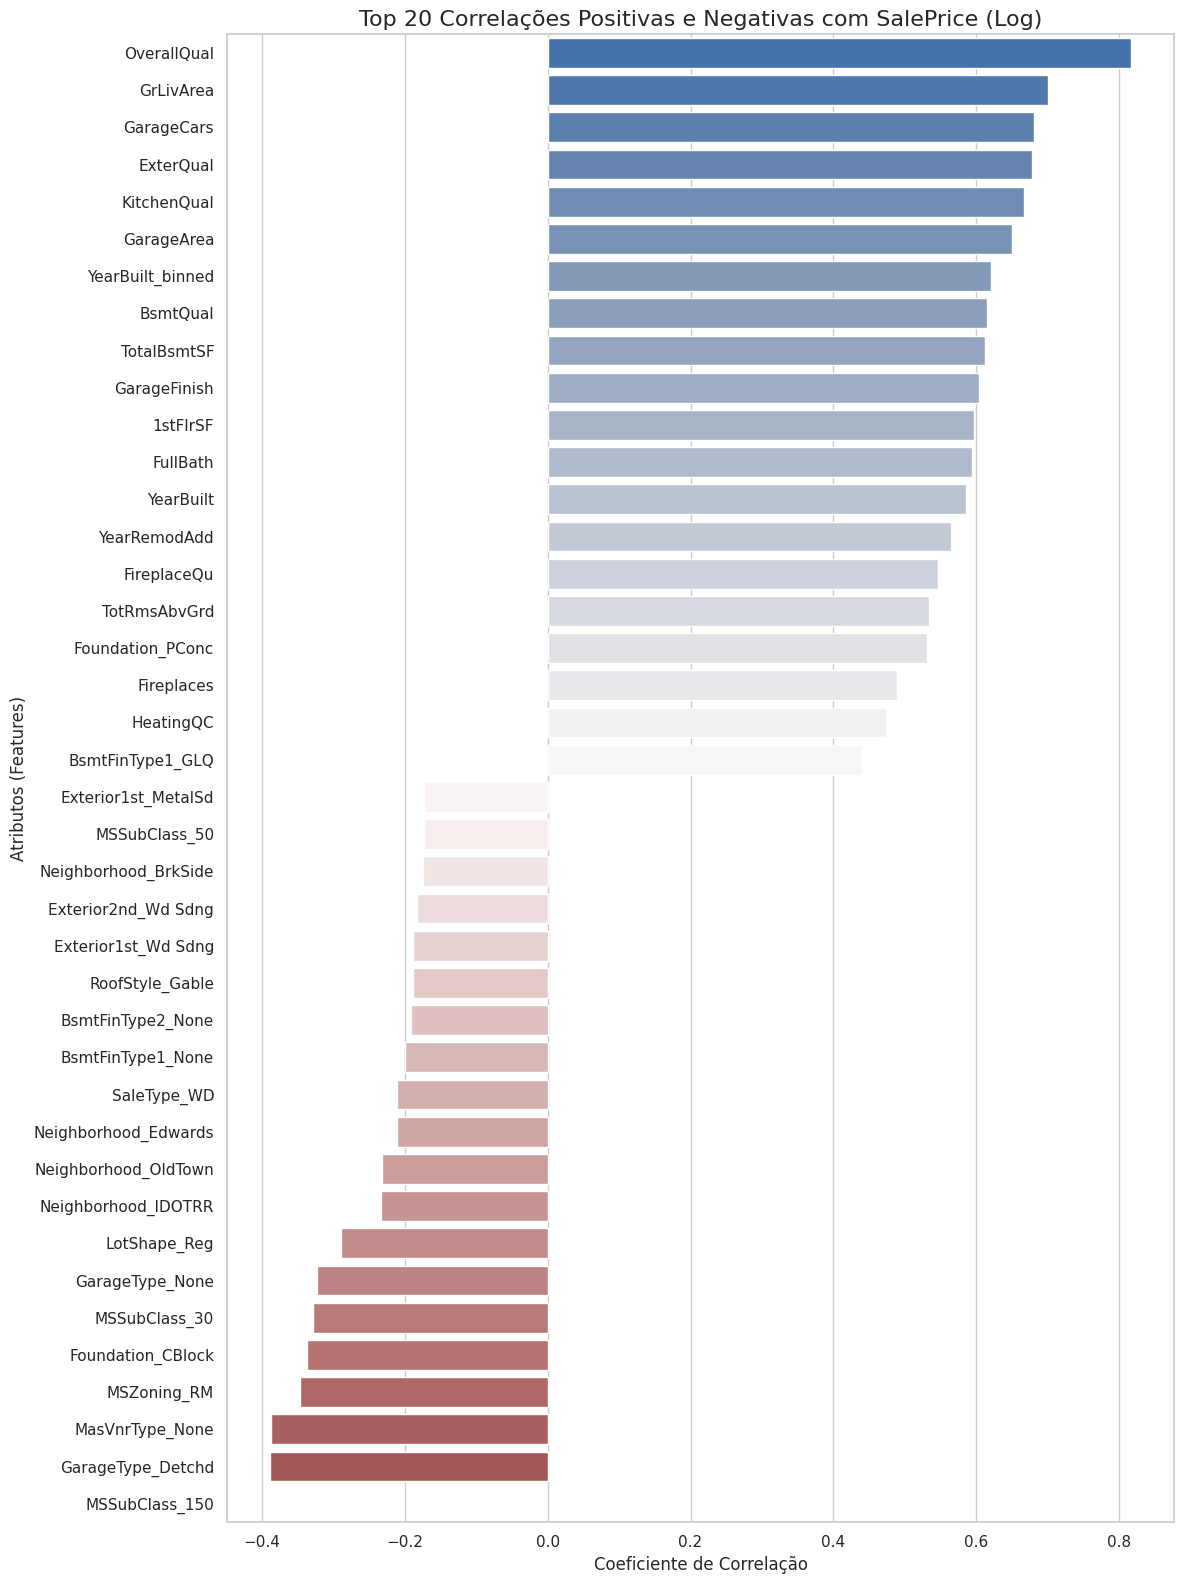

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_correlacao_com_alvo(df_features, target_series, top_n=20):
    """
    Calcula e plota a correlação das features com a série alvo.

    Args:
        df_features (pd.DataFrame): DataFrame com as features processadas.
        target_series (pd.Series): Série com a variável alvo (já em log).
        top_n (int): Número de features mais correlacionadas para exibir.
    """
    # Adicionar a variável alvo de volta ao dataframe para calcular a correlação
    df_corr = df_features.copy()
    df_corr['SalePrice_Log'] = target_series.values

    # Calcular a matriz de correlação e pegar a série de correlação com o alvo
    corr_matrix = df_corr.corr()
    corr_with_target = corr_matrix['SalePrice_Log'].sort_values(ascending=False)

    # Remover a própria variável alvo da série
    corr_with_target = corr_with_target.drop('SalePrice_Log')

    # Selecionar as N maiores correlações positivas e N menores (mais negativas)
    top_correlations = pd.concat([corr_with_target.head(top_n),
                                  corr_with_target.tail(top_n)])

    # Plotar o gráfico de barras
    plt.figure(figsize=(12, 16))
    sns.set_style("whitegrid")
    sns.barplot(x=top_correlations.values, y=top_correlations.index, palette="vlag")
    plt.title(f'Top {top_n} Correlações Positivas e Negativas com SalePrice (Log)', fontsize=16)
    plt.xlabel('Coeficiente de Correlação', fontsize=12)
    plt.ylabel('Atributos (Features)', fontsize=12)
    plt.tight_layout()
    plt.savefig('correlacao_atributos_processados.png')
    plt.show()

# Exemplo de chamada (usando os dados do seu notebook):
X_train_processed = all_data.iloc[:len(train_df)]
y_train_log = np.log1p(y_train)
plotar_correlacao_com_alvo(X_train_processed, y_train_log, top_n=20)

## 2.f Normalização de Atributos Numéricos

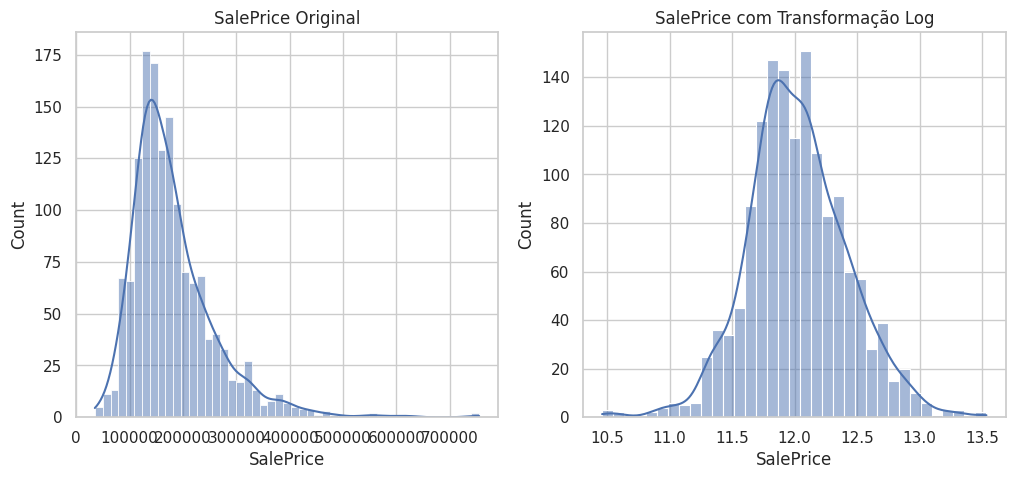

Shape do conjunto de treino final (X): (1460, 238)
Shape do conjunto de teste final (X_test): (1459, 238)


In [69]:
# Normalizar a variável alvo (SalePrice)
if 'y_train' in locals():
    y_train_log = np.log1p(y_train)

    # Visualizar a distribuição antes e depois da transformação
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(y_train, kde=True, ax=ax1)
    ax1.set_title('SalePrice Original')
    sns.histplot(y_train_log, kde=True, ax=ax2)
    ax2.set_title('SalePrice com Transformação Log')
    plt.show()

# Preparar dados de treino e teste finais
if not train_df.empty and not test_df.empty:
    X = all_data[:train_df.shape[0]]
    X_test = all_data[train_df.shape[0]:]

    # A normalização das features (X e X_test) pode ser feita
    # com StandardScaler dentro de um pipeline de Machine Learning,
    # o que é a prática recomendada para evitar data leakage.
    # Exemplo de como seria:
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    from sklearn.pipeline import Pipeline

    # Criando um pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ])
    pipeline.fit(X, y_train_log)
    
    print("Shape do conjunto de treino final (X):", X.shape)
    print("Shape do conjunto de teste final (X_test):", X_test.shape)

In [70]:
'''
O histograma da variável alvo, SalePrice, revelou uma forte assimetria à direita. 
Para atender às premissas de muitos modelos de regressão e estabilizar a variância, foi aplicada uma transformação logarítmica (np.log1p). 
O gráfico resultante mostra que a variável transformada se assemelha muito mais a uma distribuição normal, o que é ideal para a etapa de modelagem.
'''

'\nO histograma da variável alvo, SalePrice, revelou uma forte assimetria à direita. \nPara atender às premissas de muitos modelos de regressão e estabilizar a variância, foi aplicada uma transformação logarítmica (np.log1p). \nO gráfico resultante mostra que a variável transformada se assemelha muito mais a uma distribuição normal, o que é ideal para a etapa de modelagem.\n'